In [42]:
import pandas as pd
df=pd.read_csv(r'D:\Main project\neo stat\Data\Sample_Data_Ingestion.csv')

#displaying the first 5 row of the dataframe
print(df.head())

#checking is there any null values in the dataset
print("Null values : ",df.isnull().sum())

#info about the dataset
print("Information about the dataset : ",df.info())

#checking the shape and size attributes
print("Shape of the data",df.shape)
print("Size of the data",df.size)

#checking duplicates 
print("Duplicates rows :",df.duplicated().sum())



                              Server_ID      Hostname      IP_Address  \
0  536c9e75-40a1-4a74-8ca6-c6abaec13999     srv-web02     100.33.3.46   
1  26bae71d-c025-4082-9484-ef7aa9e04836     srv-web02  249.168.171.15   
2  454de38a-5961-490f-9d46-d20663a36baf  srv-backup02   248.247.52.48   
3  8b8a3f40-1b67-4fe6-a65e-93fd07f317f7     srv-web02  87.221.187.138   
4  375cb3db-89d3-4705-af4a-8f829cce1928     srv-app02    168.8.91.217   

                    OS_Type  Server_Location  CPU_Utilization (%)  \
0       Windows Server 2022  Berlin, Germany                28.10   
1              Ubuntu 20.04       London, UK                49.72   
2  Red Hat Enterprise Linux    New York, USA                44.72   
3  Red Hat Enterprise Linux    New York, USA                37.69   
4       Windows Server 2022     Tokyo, Japan                63.97   

   Memory_Usage (%)  Disk_IO (%)  Network_Traffic_In (MB/s)  \
0             88.60        28.36                      31.13   
1             84.35 

In [43]:
#converting the log timestamp to datatime 

df["Log_Timestamp"] = pd.to_datetime(df["Log_Timestamp"],dayfirst=True)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Server_ID                   200 non-null    object        
 1   Hostname                    200 non-null    object        
 2   IP_Address                  200 non-null    object        
 3   OS_Type                     200 non-null    object        
 4   Server_Location             200 non-null    object        
 5   CPU_Utilization (%)         200 non-null    float64       
 6   Memory_Usage (%)            200 non-null    float64       
 7   Disk_IO (%)                 200 non-null    float64       
 8   Network_Traffic_In (MB/s)   200 non-null    float64       
 9   Network_Traffic_Out (MB/s)  200 non-null    float64       
 10  Uptime (Hours)              200 non-null    float64       
 11  Downtime (Hours)            200 non-null    float64       

In [44]:
#checking the cpu and memory and disk usages outliers or unrealistic records

df=df[(df["CPU_Utilization (%)"]<=100)& (df['Memory_Usage (%)']<=100) & (df['Disk_IO (%)']<=100)]
df.shape

(200, 16)

In [45]:
#verifying is there unique server id

df = df.drop_duplicates(subset=["Server_ID", "Log_Timestamp"])
print("Rows after cleaning: ",df.shape[0])

Rows after cleaning:  200


In [46]:
# creating new metrics

df['Average_network_traffic']=((df["Network_Traffic_In (MB/s)"])+(df["Network_Traffic_Out (MB/s)"]))/2
df['Total_network_traffic ']=((df["Network_Traffic_In (MB/s)"])+(df["Network_Traffic_Out (MB/s)"]))
df['Availability ']=(df["Uptime (Hours)"]/(df["Uptime (Hours)"] + df["Downtime (Hours)"]))*100

def cpu_status(n):
    if 0<n<=60:
        return "Normal"
    elif 60<n<=80:
        return 'Warning'
    elif n>80:
        return "Critical"
    
df["cpu_status"]=df["CPU_Utilization (%)"].apply(cpu_status)



In [47]:
#save the processed dataset

df.to_csv("preprocessed_data.csv",index=False)

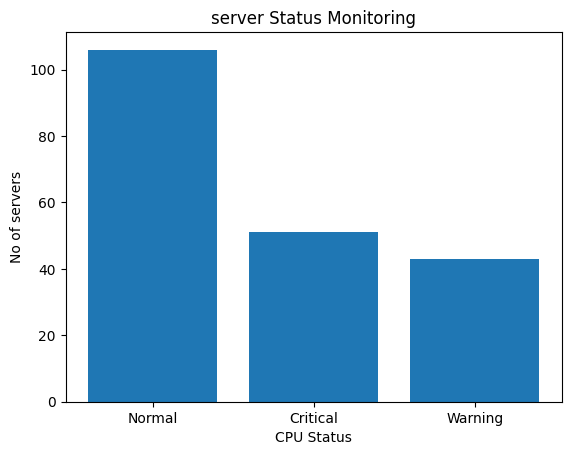

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
data=pd.read_csv(r"D:\Main project\neo stat\Data\preprocessed_data.csv")
status_counts = data['cpu_status'].value_counts()
plt.bar(status_counts.index, status_counts.values)
plt.xlabel("CPU Status")
plt.ylabel("No of servers")
plt.title("server Status Monitoring")
plt.show()